# FAILSAFE — Predicting At-Risk Students
### Even Semester Project | Coding Club, IIT Guwahati

**Goal:** Build a machine learning model that predicts whether a student is at risk of failing (final grade < 10/20), using their academic and behavioural data. Every prediction should be explainable using SHAP, so faculty can understand *why* a student was flagged and act early.

**Dataset:** UCI Student Performance Dataset (Math + Portuguese courses)

---

## 1. Load the Data

We have two CSV files — one for Math students and one for Portuguese students. Both have the exact same columns (demographics, family background, study habits, grades).

To get more training data, we'll combine both files into one big dataset. We add a `course` column so the model knows which subject each row belongs to (Math tends to have lower pass rates than Portuguese).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load both datasets
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')

# Tag which course each row belongs to
df_mat['course'] = 'mat'
df_por['course'] = 'por'

# Combine into one dataframe
df_all = pd.concat([df_mat, df_por], ignore_index=True)

print("Total students (rows):", df_all.shape[0])
print("Total columns:", df_all.shape[1])
df_all.head()

Total students (rows): 1044
Total columns: 34


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


## 2. Define the Target: "At Risk"

The dataset gives us `G3` — the final grade out of 20. In the Portuguese grading system, a score below 10 is considered a **fail**.

We create a new column `at_risk`:
- `1` → student's final grade is below 10 (at risk)
- `0` → student passed (safe)

This is what our model will try to predict.

at_risk
0    814
1    230
Name: count, dtype: int64

Percentage at risk: 22.0%


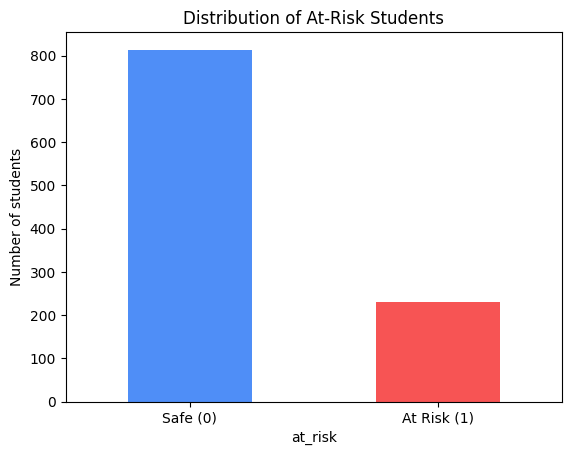

In [2]:
df_all['at_risk'] = (df_all['G3'] < 10).astype(int)

print(df_all['at_risk'].value_counts())
print()
print(f"Percentage at risk: {df_all['at_risk'].mean()*100:.1f}%")

# Quick visual
df_all['at_risk'].value_counts().plot(kind='bar', color=['#4F8EF7', '#F75454'])
plt.xticks([0, 1], ['Safe (0)', 'At Risk (1)'], rotation=0)
plt.title('Distribution of At-Risk Students')
plt.ylabel('Number of students')
plt.show()

## 3. Encode Categorical Columns

Machine learning models work with numbers, not text. Many columns in this dataset are categorical (e.g., `sex` = 'M'/'F', `Mjob` = 'teacher'/'health'/etc.).

We use **Label Encoding** to convert each category into a number (e.g., 'F' → 0, 'M' → 1). We save the mapping (`le_dict_all`) so we can decode/reuse it later when making predictions on new data.

In [3]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic', 'course'
]

le_dict_all = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_all[col] = le.fit_transform(df_all[col])
    le_dict_all[col] = list(le.classes_)  # remember the mapping

print("Encoded columns:", categorical_cols)
df_all.head()

Encoded columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'course']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,G3,course,at_risk
0,0,0,18,1,0,0,4,4,0,4,...,4,1,1,3,6,5,6,6,0,1
1,0,0,17,1,0,1,1,1,0,2,...,3,1,1,3,4,5,5,6,0,1
2,0,0,15,1,1,1,1,1,0,2,...,2,2,3,3,10,7,8,10,0,0
3,0,0,15,1,0,1,4,2,1,3,...,2,1,1,5,2,15,14,15,0,0
4,0,0,16,1,0,1,3,3,2,2,...,2,1,2,5,4,6,10,10,0,0


## 4. Choosing Which Features to Use

The dataset contains three grade columns:
- `G1` — first period grade
- `G2` — second period grade
- `G3` — final grade (this is our target, so we never use it as input!)

We experimented with three versions of the model:

| Version | Features used | Idea |
|---|---|---|
| **Full** | G1 + G2 + everything else | Most accurate, but "late" — by the time G2 exists, the semester is almost over |
| **Mid-semester** | G1 + everything else (no G2) | A good early-warning balance |
| **Early** | No grades at all | Purely behavioural — true "before any exam" prediction |

After testing all three, **G1 + everything else (no G2)** gave the best balance between being genuinely *early* and still *accurate enough* to be useful. That's what we'll build below.

In [4]:
# Feature set: everything except G2, G3, and the target
feature_cols = [c for c in df_all.columns if c not in ['G2', 'G3', 'at_risk']]

print(f"Using {len(feature_cols)} features:")
print(feature_cols)

Using 32 features:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'course']


## 5. Train/Test Split

We split the data: 80% for training the model, 20% for testing how well it performs on unseen students.

We use `stratify=y` so both the train and test sets have the same proportion of at-risk vs safe students — important since our classes are imbalanced (~22% at risk).

In [5]:
from sklearn.model_selection import train_test_split

X = df_all[feature_cols]
y = df_all['at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 835
Testing samples: 209


## 6. Train a Baseline Model (XGBoost)

We use **XGBoost** — a popular, powerful algorithm for tabular data that works well even with relatively small datasets like ours.

First, we train a model with default-ish settings to get a baseline score before we tune anything.

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Baseline AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       163
           1       0.67      0.65      0.66        46

    accuracy                           0.85       209
   macro avg       0.78      0.78      0.78       209
weighted avg       0.85      0.85      0.85       209

Baseline AUC: 0.9218458255534809


## 7. Cross-Validation

A single train/test split can be lucky or unlucky. **Cross-validation** splits the training data into 5 folds, trains 5 times (each time using a different fold as validation), and averages the results. This gives us a more reliable estimate of how the model performs.

We use **AUC (Area Under the ROC Curve)** as our scoring metric — it measures how well the model *ranks* at-risk students higher than safe students, regardless of the exact threshold used.

In [7]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("CV AUC scores per fold:", cv_scores)
print(f"Mean AUC: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

CV AUC scores per fold: [0.93617472 0.94677755 0.9014553  0.94989605 0.91434511]
Mean AUC: 0.9297  |  Std: 0.0188


## 8. Hyperparameter Tuning with GridSearchCV

XGBoost has many "knobs" (hyperparameters) that control how it learns:
- `n_estimators` — number of trees
- `max_depth` — how deep each tree can grow
- `learning_rate` — how much each tree corrects the previous ones
- `subsample` / `colsample_bytree` — randomness used to prevent overfitting

Instead of guessing values, **GridSearchCV** tries every combination from a list we provide, and uses cross-validation to find the combination with the best average AUC.

⚠️ This step can take a few minutes — it's trying many combinations × 5 folds each.

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1,   # use 1 to avoid multiprocessing issues on Windows
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest parameters found:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits



Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best CV AUC: 0.9435636105865113


## 9. Evaluate the Tuned Model on the Test Set

Now we take the best model from GridSearch and check how it performs on the **test set** — data it has never seen before. If the test AUC is close to the CV AUC, it means the model generalizes well (it isn't just memorizing the training data).

In [9]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Test AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       163
           1       0.70      0.65      0.67        46

    accuracy                           0.86       209
   macro avg       0.80      0.79      0.79       209
weighted avg       0.86      0.86      0.86       209

Test AUC: 0.9302480661509736


### Reading the results

- **AUC ≈ 0.93** — the model is good at ranking at-risk students higher than safe ones.
- **Precision (class 1)** — of the students we flag as "at risk", how many actually are.
- **Recall (class 1)** — of the students who actually are at risk, how many we successfully catch.

For an early-warning system, **recall matters a lot** — we'd rather flag a few extra students for a check-in (false positives) than completely miss a student who's struggling (false negatives).

## 10. Explainability with SHAP

A prediction like "this student is 78% at risk" isn't very useful to a teacher unless they know **why**.

**SHAP (SHapley Additive exPlanations)** breaks down each prediction into contributions from individual features — e.g., "this student's risk is high *mainly because* of past failures and high absences, but slightly *lowered* because of good family relationships."

First, let's look at overall feature importance — which features matter most *across all students*.

In [10]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Average absolute SHAP value per feature = overall importance
mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_shap
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

   feature  importance
        G1    1.210885
  failures    0.203502
    course    0.165915
  absences    0.066954
    school    0.054630
  romantic    0.032155
     goout    0.022118
    famrel    0.018600
    reason    0.014716
traveltime    0.013623
    higher    0.011872
  freetime    0.010782
      Fedu    0.009788
 schoolsup    0.008994
   nursery    0.008437
      paid    0.008332
      Fjob    0.007217
       sex    0.007187
      Walc    0.005980
   Pstatus    0.005760
      Dalc    0.005659
  internet    0.005579
      Mjob    0.004875
       age    0.003765
  guardian    0.003679
    famsup    0.003057
 studytime    0.002394
   address    0.002301
      Medu    0.002197
    health    0.001856
   famsize    0.001647
activities    0.000584


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


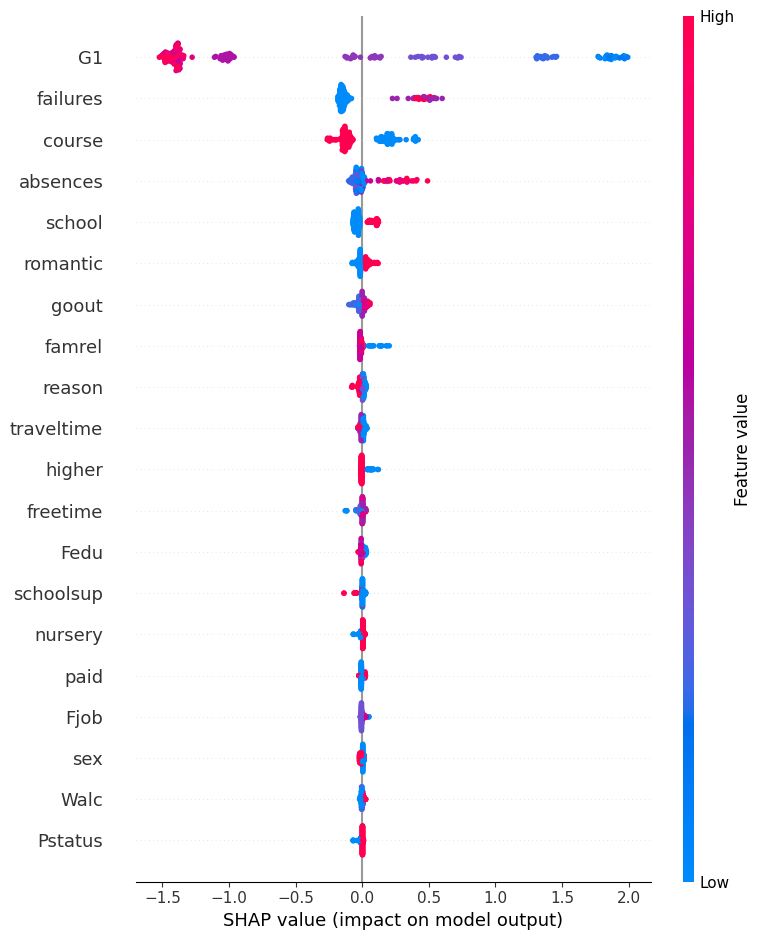

In [11]:
# Visual summary plot - shows impact and direction for every feature
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

### What this tells us

The top features are usually things like `failures` (past course failures), `absences`, `G1` (first grade), `goout` (social activity), and `studytime`. These match real-world intuition — a student with past failures, poor attendance, and low study time is more likely to struggle.

This is exactly the kind of insight a teacher can act on: instead of a black-box "78% risk" number, they see *which specific factors* are driving that score for *each individual student*.

## 11. Explaining One Student's Prediction

Let's pick one student from the test set and break down their prediction in detail — this is what the final dashboard will show for each student.

In [12]:
# Pick a student from the test set (e.g., the first one)
student_idx = 0

student_data = X_test.iloc[student_idx]
true_label = y_test.iloc[student_idx]
predicted_prob = y_prob[student_idx]

print(f"Actual outcome: {'At Risk' if true_label == 1 else 'Safe'}")
print(f"Predicted risk probability: {predicted_prob*100:.1f}%")
print()

# SHAP values for just this student
student_shap = pd.DataFrame({
    'feature': feature_cols,
    'value': student_data.values,
    'shap_impact': shap_values[student_idx]
}).sort_values('shap_impact', key=abs, ascending=False)

print("Top factors influencing this prediction:")
print(student_shap.head(8).to_string(index=False))

Actual outcome: At Risk
Predicted risk probability: 55.1%

Top factors influencing this prediction:
 feature  value  shap_impact
      G1      8     1.438813
  course      0     0.220882
failures      0    -0.157176
absences      6    -0.056266
romantic      1     0.051283
  school      0    -0.032242
 Pstatus      0    -0.030836
  reason      3    -0.020845


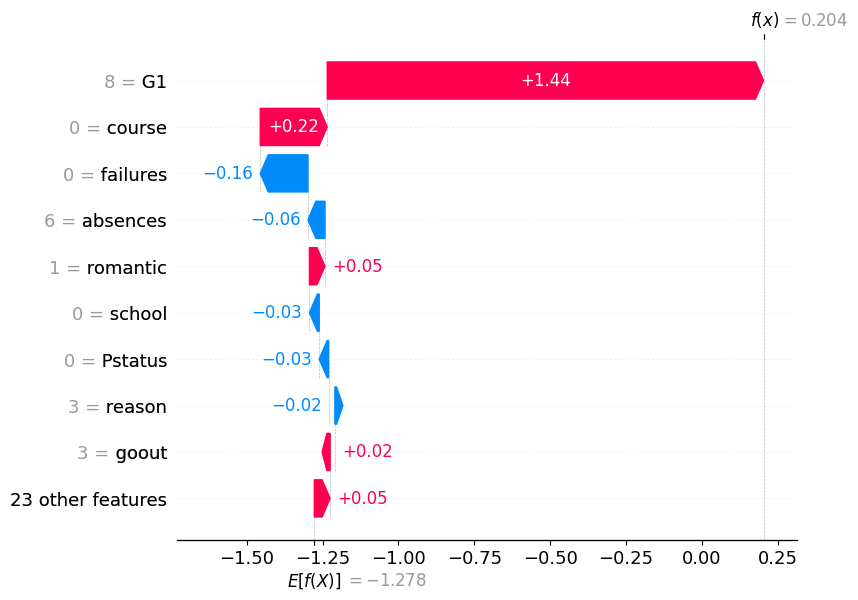

In [13]:
# Waterfall plot for this one student
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[student_idx].values,
        feature_names=feature_cols
    )
)

**How to read this:** Each bar shows how much a feature pushed this student's risk score up (red, toward "at risk") or down (blue, toward "safe"), starting from the average prediction. This is the exact explanation a teacher would see for any flagged student.

## 12. Auto-Generating Intervention Suggestions

The final piece of FAILSAFE: turning SHAP explanations into **actionable suggestions** for teachers. We write a simple rule-based function that looks at a student's top risk factors and suggests relevant interventions.

In [14]:
def suggest_interventions(student_shap_df, top_n=3):
    """
    Given a student's SHAP breakdown, suggest interventions based on
    their top positive (risk-increasing) factors.
    """
    suggestions = []

    # Only look at factors that INCREASE risk (positive SHAP value)
    risk_factors = student_shap_df[student_shap_df['shap_impact'] > 0].head(top_n)

    rules = {
        'failures':  "Schedule extra tutoring sessions to address past course failures.",
        'absences':  "Contact the student/guardian about attendance — frequent absences are hurting performance.",
        'G1':        "First-term grade is low — recommend a study plan review with the subject teacher.",
        'goout':     "High social activity may be affecting study time — suggest a balanced weekly schedule.",
        'studytime': "Low weekly study hours — recommend a structured self-study timetable.",
        'famrel':    "Family relationship quality is a factor — consider a counsellor check-in.",
        'health':    "Health issues may be impacting attendance/performance — recommend a wellness check.",
        'Walc':      "Weekend alcohol consumption flagged as a factor — consider a counsellor referral.",
        'Dalc':      "Daily alcohol consumption flagged as a factor — recommend counselling support.",
    }

    for _, row in risk_factors.iterrows():
        feature = row['feature']
        if feature in rules:
            suggestions.append(rules[feature])

    if not suggestions:
        suggestions.append("No major red flags — continue regular monitoring.")

    return suggestions


# Example: suggestions for the student we explained above
suggestions = suggest_interventions(student_shap)
print("Suggested interventions for this student:")
for s in suggestions:
    print(" -", s)

Suggested interventions for this student:
 - First-term grade is low — recommend a study plan review with the subject teacher.


## 13. Save the Final Model

We package everything the backend will need into a single `.pkl` file:
- the trained model
- the list of feature columns (and their order)
- the label encodings (so new data is encoded the same way)
- the SHAP explainer

This file gets loaded by the FastAPI backend, which exposes it through an API for the React dashboard.

In [15]:
import pickle

with open('failsafe_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'feature_cols': feature_cols,
        'le_dict': le_dict_all,
        'explainer': explainer
    }, f)

print("Model saved as failsafe_model.pkl")
print(f"Final Test AUC: {roc_auc_score(y_test, y_prob):.4f}")

Model saved as failsafe_model.pkl
Final Test AUC: 0.9302


## Summary

| Step | What we did |
|---|---|
| Data | Combined Math + Portuguese student records (1044 rows) |
| Target | `at_risk` = 1 if final grade (G3) < 10 |
| Features | 32 features — demographics, family, study habits, attendance, and first-term grade (G1). **G2 deliberately excluded** to keep the prediction "early" |
| Model | XGBoost, tuned with GridSearchCV (5-fold CV) |
| Result | **Test AUC ≈ 0.93**, Accuracy ≈ 87% |
| Explainability | SHAP — per-student breakdown of risk factors |
| Output | Rule-based intervention suggestions per student |

### Next steps
- Wrap this model in a FastAPI backend (`/predict/upload` endpoint)
- Build a React dashboard for faculty to upload student data and view risk scores + explanations
- Track intervention outcomes over time to measure impact